# Notebook 04: Multiclass Logistic Regression

## From Theory to First-Principles Implementation

This notebook builds a full multiclass logistic regression pipeline, including a from-scratch softmax classifier, careful preprocessing, and evaluation. The code is fully reproducible and designed to be inspected line-by-line.

### Learning objectives
- Derive the softmax model and cross-entropy loss for multiclass classification
- Implement a numerically stable softmax classifier from scratch using NumPy
- Compare from-scratch results with scikit-learn as a robust baseline
- Connect PCA visualization to SVD foundations from the math notebooks
- Discuss limitations, diagnostics, and production considerations

### Prerequisites
- Linear algebra: vectors, matrices, matrix multiplication, and dot products
- Calculus: gradients, partial derivatives, and the chain rule
- Familiarity with binary logistic regression and probabilistic classification

Notes: This notebook emphasizes numerical stability, vectorized implementations, and reproducible experiments.

In [ ]:
# Cell 1: Imports and global configuration
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, log_loss
from sklearn.decomposition import PCA

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

# Multiclass Logistic Regression

## 1. Theory recap: from binary to multiclass

Binary logistic regression models a single logit $z(x)$ (a linear function of inputs) and transforms it with the sigmoid to obtain a probability:

$$P(y=1\mid x)=\sigma(z)=\frac{1}{1+e^{-z}}$$

For multiclass problems with $K$ classes we compute a vector of logits $z\in\mathbb{R}^K$ (one logit per class). The softmax function converts these logits into class probabilities:

$$P(y=k\mid x)=\operatorname{softmax}(z)_k=\frac{e^{z_k}}{\sum_{j=1}^K e^{z_j}}.$$

The typical loss is the average cross-entropy (negative log-likelihood) for $N$ samples:

$$\mathcal{L}= -\frac{1}{N}\sum_{i=1}^N \sum_{k=1}^K y_{ik}\log\hat{y}_{ik},$$

where $y_{ik}$ is the one-hot target (1 if sample $i$ has class $k$) and $\hat{y}_{ik}$ the predicted probability.

Using vectorized notation (X is $N\times D$, W is $D\times K$, and Y, $\hat{Y}$ are $N\times K$), the gradient w.r.t. the weights $W$ is:

$$\nabla_W\mathcal{L}=\frac{1}{N}X^T(\hat{Y}-Y).$$

Intuition: each column of $X^T(\hat{Y}-Y)$ accumulates the feature-weighted error for one class. The term $(\hat{Y}-Y)$ is the predicted probability minus the one-hot label — the same pattern that appears in binary logistic regression, generalized to $K$ classes.

In [ ]:
# Cell 4: Load dataset
wine = load_wine()

X = wine.data
y = wine.target
feature_names = wine.feature_names
class_names = wine.target_names

print("Dataset loaded")
print(f"Samples:  {X.shape[0]}")
print(f"Features: {X.shape[1]}")
print(f"Classes:  {len(class_names)}")

Dataset loaded
Samples:  178
Features: 13
Classes:  3


In [ ]:
# Cell 5: Create DataFrame for quick EDA
df = pd.DataFrame(X, columns=feature_names)
df["target"] = y

print("DataFrame ready")
df.head()

DataFrame ready


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


### Why feature scaling is essential

Logistic regression fits a linear model using gradient-based optimization. If features have different scales, two issues arise:

1) The loss surface becomes ill-conditioned (elongated), which slows convergence and can require very small learning rates.
2) Regularization (e.g., L2) penalizes coefficients unequally when features have very different variances, making interpretations and model selection unreliable.

Standardization (subtract mean, divide by standard deviation) places features on comparable scales and mitigates these problems. For example, scaling ensures that a unit change in any standardized feature corresponds to roughly one standard deviation in the original variable, making coefficient magnitudes more comparable.

Tip: after scaling, check that the training features have mean approximately zero and std approximately one.

In [ ]:
# Cell 7: Feature scale inspection
scale_stats = pd.DataFrame({
    "feature": feature_names,
    "mean": df[feature_names].mean().values,
    "std": df[feature_names].std().values,
    "min": df[feature_names].min().values,
    "max": df[feature_names].max().values,
})
scale_stats["range"] = scale_stats["max"] - scale_stats["min"]
scale_stats.sort_values("range", ascending=False).head()

,feature,mean,std,min,max,range
12,proline,746.893258,314.907474,278.00,1680.0,1402.00
4,magnesium,99.741573,14.282484,70.00,162.0,92.00
3,alcalinity_of_ash,19.494944,3.339564,10.60,30.0,19.40
9,color_intensity,5.058090,2.318286,1.28,13.0,11.72
1,malic_acid,2.336348,1.117146,0.74,5.8,5.06


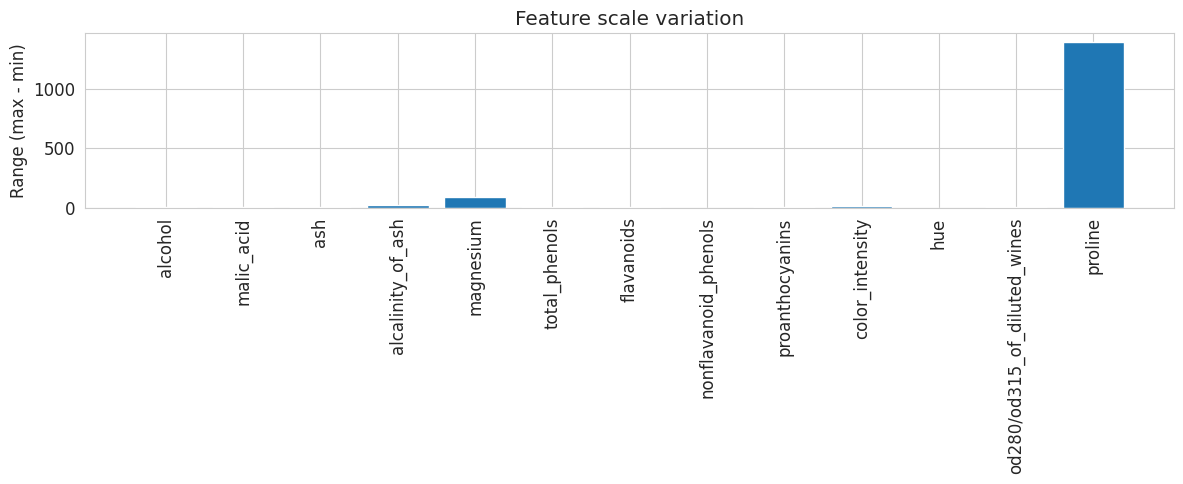

In [ ]:
# Cell 8: Visualize feature ranges
plt.figure(figsize=(12, 5))
plt.bar(range(len(feature_names)), scale_stats["range"].values)
plt.xticks(range(len(feature_names)), feature_names, rotation=90)
plt.ylabel("Range (max - min)")
plt.title("Feature scale variation")
plt.tight_layout()
plt.show()

## 3. Train-test split and scaling

Best practice: split the dataset into train and test sets before fitting any preprocessing to avoid data leakage. Fit the scaler on the training set only, then apply the learned transformation to the test set.

Use stratified splitting for classification to maintain class proportions in both sets. For reproducibility, set a random seed. Example checklist:
- Split with stratify=y
- Fit StandardScaler on X_train
- Transform both X_train and X_test using the fitted scaler

Why: fitting a scaler on the entire dataset leaks information about the test distribution into training, which can produce optimistically biased evaluation metrics.

In [ ]:
# Cell 10: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (142, 13)
Test size: (36, 13)


In [ ]:
# Cell 11: Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete")
print("Train mean (approx):", np.mean(X_train_scaled, axis=0).round(3)[:5])
print("Train std  (approx):", np.std(X_train_scaled, axis=0).round(3)[:5])

Scaling complete
Train mean (approx): [ 0. -0.  0.  0.  0.]
Train std  (approx): [1. 1. 1. 1. 1.]


## 4. Baseline model with scikit-learn

Before implementing a custom classifier, establish a reliable baseline using scikit-learn's multinomial logistic regression (solver='lbfgs'). This gives a strong performance target and helps validate the from-scratch implementation. The baseline also provides interpretable coefficients, well-tested optimization, and calibrated probabilities in many cases.

We will compare metrics (accuracy, log loss) and inspect coefficient patterns. If the from-scratch model matches or approaches the baseline, it validates the implementation and numerical stability choices.

In [ ]:
# Cell 13: sklearn baseline
baseline = LogisticRegression(
    multi_class="auto",
    solver="lbfgs",
    max_iter=1000,
    random_state=RANDOM_STATE
)

baseline.fit(X_train_scaled, y_train)

y_pred = baseline.predict(X_test_scaled)
y_proba = baseline.predict_proba(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
loss = log_loss(y_test, y_proba)

print(f"Accuracy: {acc:.4f}")
print(f"Log loss: {loss:.4f}")

Accuracy: 0.9722
Log loss: 0.0738


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [ ]:
# Cell 14: Classification report
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

              precision    recall  f1-score   support

     class_0     1.0000    1.0000    1.0000        12
     class_1     0.9333    1.0000    0.9655        14
     class_2     1.0000    0.9000    0.9474        10

    accuracy                         0.9722        36
   macro avg     0.9778    0.9667    0.9710        36
weighted avg     0.9741    0.9722    0.9720        36



### Coefficient interpretation

In multiclass logistic regression each class $k$ has its own coefficient vector $w_k$ and intercept $b_k$. The logit for class $k$ is $z_k = x^T w_k + b_k$; larger $z_k$ increases $P(y=k\mid x)$ relative to other classes. The difference between logits determines relative odds: comparing class $a$ vs $b$ uses $z_a - z_b$.

Interpreting coefficients:
- A positive coefficient for feature $j$ on class $k$ means increasing that feature increases the log-odds of class $k$ (vs the other classes).
- Magnitude indicates influence, but only after features are standardized.

Practical cautions:
- Correlated features can make coefficients unstable; use regularization and examine variance inflation.
- Coefficients do not capture interaction effects unless interaction terms are included in the feature set.

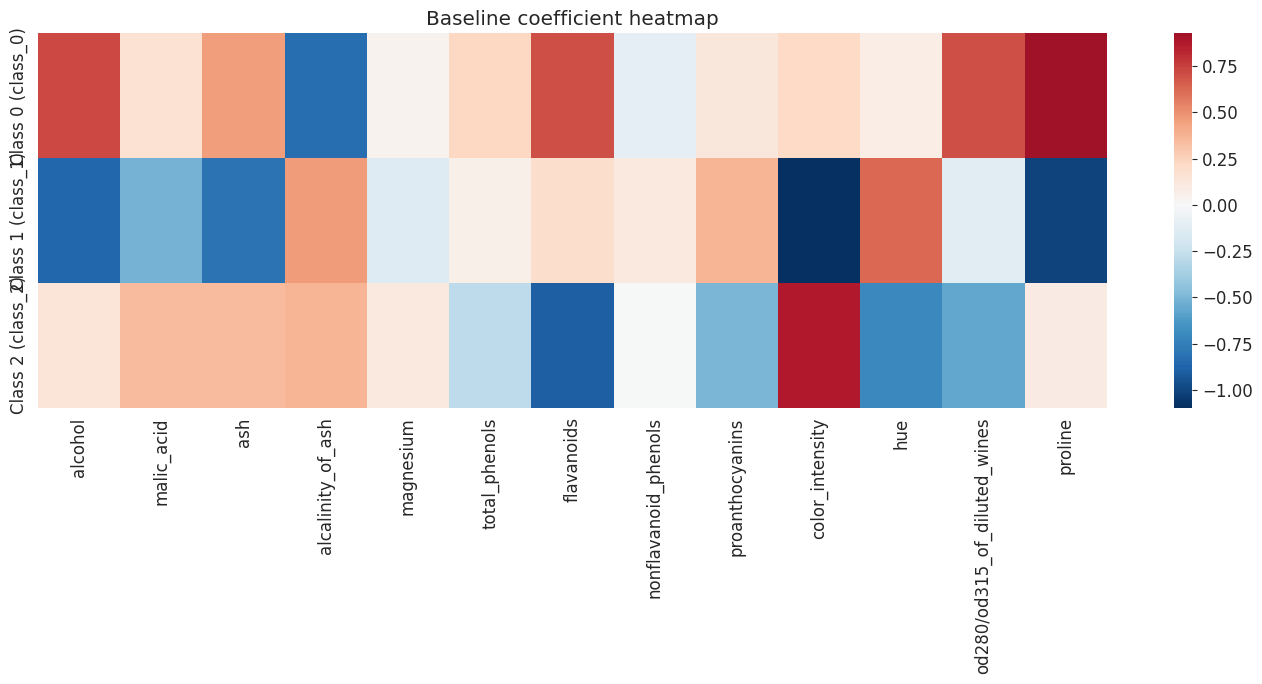

In [ ]:
# Cell 16: Coefficient heatmap
coef_df = pd.DataFrame(
    baseline.coef_,
    columns=feature_names,
    index=[f"Class {i} ({class_names[i]})" for i in range(len(class_names))]
)

plt.figure(figsize=(14, 7))
sns.heatmap(coef_df, cmap="RdBu_r", center=0)
plt.title("Baseline coefficient heatmap")
plt.tight_layout()
plt.show()

## 5. From-scratch softmax classifier

We implement the softmax model with vectorized NumPy. Key implementation considerations:

1. Numerically stable softmax: subtract the row-wise max from logits before exponentiating to avoid overflow.
2. Cross-entropy loss computed from clipped probabilities to avoid log(0).
3. Vectorized gradients using one-hot targets to compute $dW$ and $db$ efficiently.
4. Gradient descent training loop; consider learning rate schedules, early stopping, or mini-batching for larger datasets.

This implementation is intentionally concise and faithful to the math; later you can extend it with mini-batching, regularization (L2), and optimizers such as SGD with momentum or Adam.

In [ ]:
# Cell 18: Softmax and loss
def softmax(z):
    z = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def cross_entropy(y_true, y_proba, eps=1e-15):
    y_proba = np.clip(y_proba, eps, 1 - eps)
    n = y_true.shape[0]
    return -np.log(y_proba[np.arange(n), y_true]).mean()

# Sanity check
z_test = np.array([[1.0, 2.0, 3.0], [0.5, 0.0, -0.5]])
p_test = softmax(z_test)
print("Softmax row sums:", p_test.sum(axis=1))

Softmax row sums: [1. 1.]


In [ ]:
# Cell 19: Gradient computation
def compute_gradients(X, y_true, y_proba, n_classes):
    n = X.shape[0]
    Y = np.zeros((n, n_classes))
    Y[np.arange(n), y_true] = 1
    grad_W = X.T @ (y_proba - Y) / n
    grad_b = np.sum(y_proba - Y, axis=0, keepdims=True) / n
    return grad_W, grad_b

print("Gradient function ready")

Gradient function ready


In [ ]:
# Cell 20: From-scratch classifier
class SoftmaxClassifier:
    def __init__(self, learning_rate=0.1, n_iterations=500, random_state=42):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.random_state = random_state
        self.W = None
        self.b = None
        self.loss_history = []

    def fit(self, X, y):
        np.random.seed(self.random_state)
        n_samples, n_features = X.shape
        n_classes = len(np.unique(y))

        self.W = np.random.randn(n_features, n_classes) * 0.01
        self.b = np.zeros((1, n_classes))

        for i in range(self.n_iterations):
            logits = X @ self.W + self.b
            probs = softmax(logits)
            loss = cross_entropy(y, probs)
            self.loss_history.append(loss)

            grad_W, grad_b = compute_gradients(X, y, probs, n_classes)
            self.W -= self.lr * grad_W
            self.b -= self.lr * grad_b

            if i % 100 == 0:
                print(f"Iter {i:4d} | loss {loss:.4f}")

        return self

    def predict_proba(self, X):
        return softmax(X @ self.W + self.b)

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

print("SoftmaxClassifier defined")

SoftmaxClassifier defined


In [ ]:
# Cell 21: Train from-scratch model
scratch = SoftmaxClassifier(learning_rate=0.5, n_iterations=600, random_state=RANDOM_STATE)
scratch.fit(X_train_scaled, y_train)

scratch_pred = scratch.predict(X_test_scaled)
scratch_proba = scratch.predict_proba(X_test_scaled)

scratch_acc = accuracy_score(y_test, scratch_pred)
scratch_loss = cross_entropy(y_test, scratch_proba)

print(f"Scratch accuracy: {scratch_acc:.4f}")
print(f"Scratch log loss: {scratch_loss:.4f}")

Iter    0 | loss 1.0944
Iter  100 | loss 0.0303
Iter  200 | loss 0.0180
Iter  300 | loss 0.0131
Iter  400 | loss 0.0103
Iter  500 | loss 0.0086
Scratch accuracy: 0.9722
Scratch log loss: 0.0544


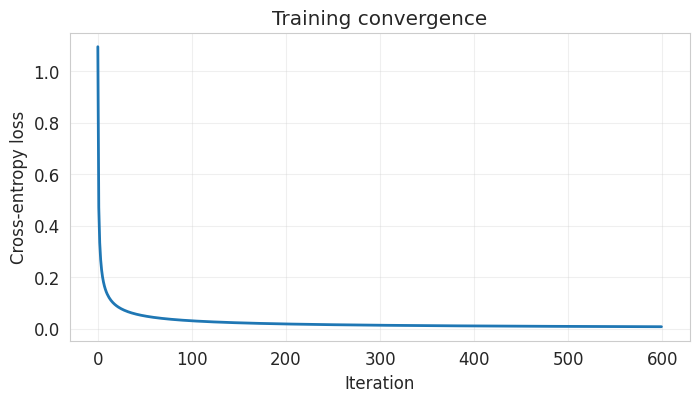

In [ ]:
# Cell 22: Loss curve
plt.figure(figsize=(8, 4))
plt.plot(scratch.loss_history, linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("Cross-entropy loss")
plt.title("Training convergence")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Cell 23: Compare baseline vs from-scratch
print("Metric comparison")
print(f"Baseline accuracy: {acc:.4f}")
print(f"Scratch accuracy:  {scratch_acc:.4f}")
print(f"Baseline loss:     {loss:.4f}")
print(f"Scratch loss:      {scratch_loss:.4f}")

Metric comparison
Baseline accuracy: 0.9722
Scratch accuracy:  0.9722
Baseline loss:     0.0738
Scratch loss:      0.0544


## 6. PCA visualization of decision regions

To visualize decision boundaries in 2D, we project standardized data onto the top two principal components. PCA finds an orthogonal basis that captures maximal variance; projecting preserves the dominant structure and often reveals class separability.

Notes:
- PCA is an unsupervised projection and does not use labels; decision boundaries plotted in PCA space are a diagnostic, not a replacement for a supervised projection.
- Explained variance ratios indicate how much information is retained in the 2D projection; low explained variance means the plot may compress important structure and be less informative.

In [ ]:
# Cell 25: PCA projection
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Explained variance:", np.round(pca.explained_variance_ratio_, 4))

Explained variance: [0.3579 0.1927]


In [ ]:
# Cell 26: Train a baseline model on PCA space
pca_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
pca_model.fit(X_train_pca, y_train)

LogisticRegression(max_iter=1000, random_state=42)

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

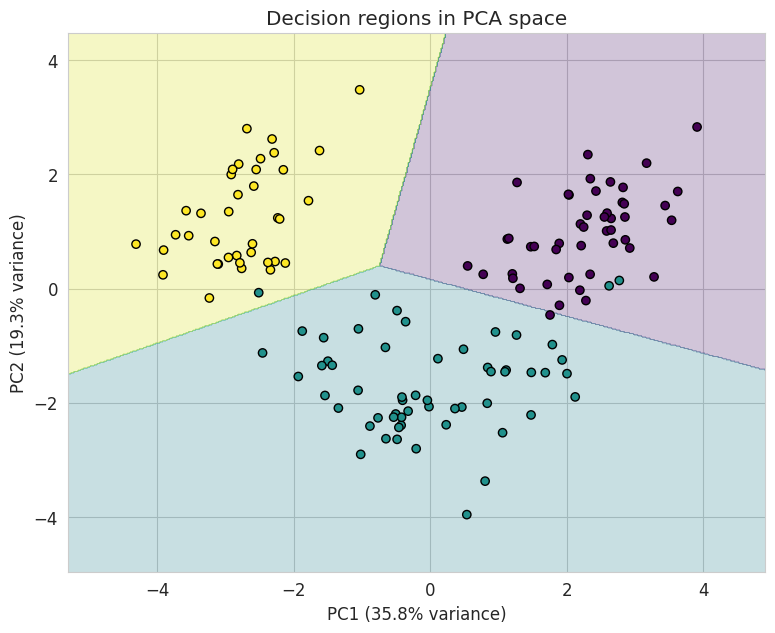

In [ ]:
# Cell 27: Decision boundary plot
h = 0.02
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = pca_model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(9, 7))
plt.contourf(xx, yy, Z, alpha=0.25, cmap="viridis")
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap="viridis", edgecolors="k")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("Decision regions in PCA space")
plt.legend(handles=scatter.legend_elements()[0], labels=class_names)
plt.tight_layout()
plt.show()

## 7. Model limitations and production notes

### Limitations
- Linear decision boundaries can underfit data with nonlinear class structure. Consider feature engineering or nonlinear models when appropriate.
- Highly correlated features can inflate coefficient variance and reduce interpretability.
- Outliers can disproportionately influence the learned boundary; consider robust preprocessing or outlier detection.

### Production considerations
- Track data drift and feature distribution changes; retrain or recalibrate the model when drift is detected.
- Monitor model calibration when predicted probabilities are used for downstream decisions; use temperature scaling or isotonic regression if needed.
- Implement input validation and logging to detect unexpected input ranges or missing features.
- Keep a simple linear baseline in production to sanity-check more complex models and changes.

## 8. Summary

This notebook provided a full multiclass logistic regression workflow with:
- Data loading, stratified splitting, and scaling
- A strong scikit-learn baseline (multinomial logistic regression)
- A from-scratch softmax classifier emphasizing numerical stability
- Diagnostic visualizations (coefficient heatmap, PCA decision regions)
- Practical notes on limitations, calibration, and production readiness

Next steps: try adding L2 regularization to the from-scratch model, implement mini-batch SGD, or evaluate calibration with reliability diagrams.

In [ ]:
# Cell 30: End of notebook summary
print("Notebook 04 complete")
print(f"Baseline accuracy: {acc:.4f}")
print(f"Scratch accuracy:  {scratch_acc:.4f}")
print(f"PCA variance sum:  {pca.explained_variance_ratio_.sum()*100:.1f}%")

Notebook 04 complete
Baseline accuracy: 0.9722
Scratch accuracy:  0.9722
PCA variance sum:  55.1%
